<a href="https://colab.research.google.com/github/franciscoweitzman-cyber/aps_francisco_weitzman/blob/main/TS3/TS3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TS3
## Análisis de Fourier: FFT, desparramo, interpolación y ventaneo
### Por: Francisco Weitzman


## Introducción
En la tarea semanal N°3, vamos a crear una sinusoidal sin ruido de 3 valores de $k_0$, la frecuencia de nuestra señal. Los valores, dos de los cuales no van a caer en un Bin, van a tener distintas formas en el dominio de frecuencias discretas. A esto se le llama derrame espectral y lo vamos a estudiar. Asimismo, vamos a aplicar la técnica del Zero Padding que consiste en agregarle muestras ficticias de valor 0 al vector de valores de nuestra señal. Esto le va a aumentar la cantidad de frecuencias que muestrea nuestra señal ya que mejora la resolución espectral $Δf=\frac{f_s}{N}$ al aumentar los N. Reduce la potencia media, pero la energía total es la misma ($P_{Media}*M$, $M$ el nuevo $N$) ya que los "0's" no agregan energía.


---


Empezamos por definir nuestros parámetros

In [4]:
import numpy as np
import matplotlib.pyplot as plt

#%% Parametros iniciales y sinudoiudal
fs = 1000 # Hz
N = 1000 # muestras
vmax=np.sqrt(2) #pot = 1W
dc = np.zeros((3,N)) # Valor medio (alrededor del que oscila)

df=fs/N # frecuencia de la señal, va a ser nuestra f0
k=N//4
ph=0
nn = np.arange(0,N).reshape(1,N)
tt=nn/fs
mu=0 #valor medio

k_0 = np.array([k,k+0.25,k+0.5]).reshape(3,1)
eje_frecuencias = np.arange(N//2) * fs/N
xx = dc+vmax*np.sin(2*np.pi*k_0*df*nn/fs+2*np.pi*ph)

Para empezar, vamos a querer graficar nuestras señales con muestreos de nuestra DTFT de 1Hz. Tomo 30 muestras nomás para que se pueda apreciar

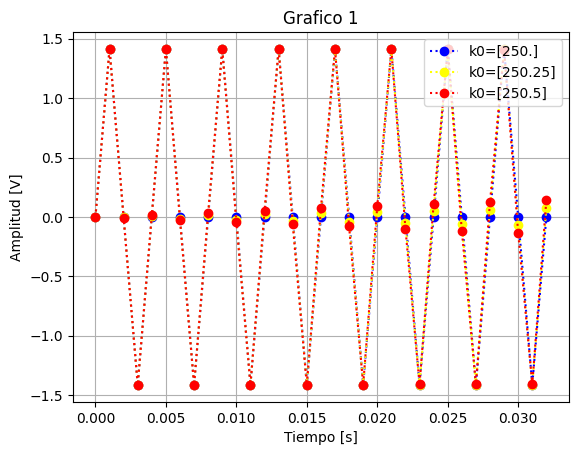

In [5]:
#%% Grafico 1
plt.figure()
plt.title('Grafico 1')

plt.plot(tt[0,:N//30],xx[0,:N//30], ':o', color="blue", label = f'k0={k_0[0]}')
plt.plot(tt[0,:N//30],xx[1,:N//30], ':o', color="yellow", label = f'k0={k_0[1]}')
plt.plot(tt[0,:N//30],xx[2,:N//30], ':o', color="red", label = f'k0={k_0[2]}')

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.grid(True) #Para mostrar una grilla de fondo
plt.legend()
plt.show()

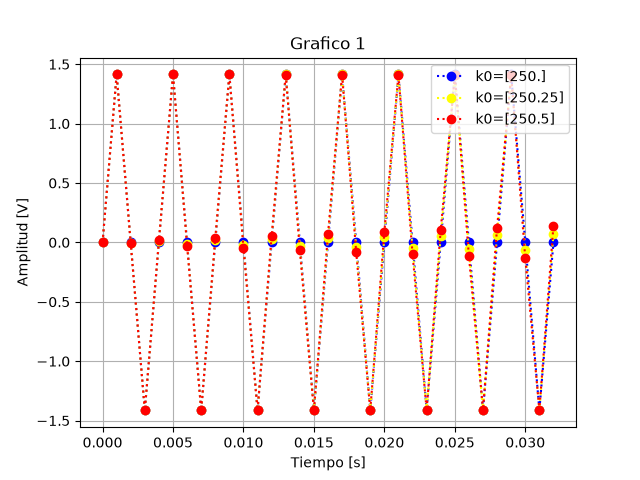

Acá se puede apreciar las señales de distinta frecuencia

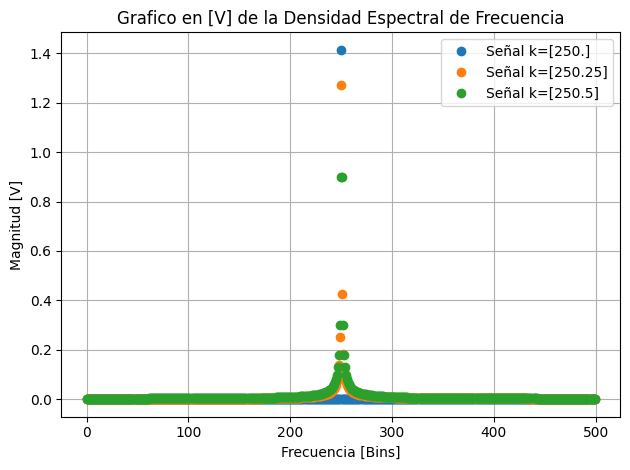

In [6]:
#%% FFT
fft = np.fft.fft(xx,axis=1)/N
modulo = np.abs(fft[:,:N//2])
modulo[:, 1:] = 2 * modulo[:, 1:] # Por la simetría en la f_nyquist
modulo_db = 20*np.log10(modulo/vmax)

plt.figure()
plt.title("Grafico en [V] de la Densidad Espectral de Frecuencia")
plt.plot(eje_frecuencias[:], modulo[0,:], 'o', label = f'Señal k={k_0[0]}')
plt.plot(eje_frecuencias[:], modulo[1,:], 'o', label = f'Señal k={k_0[1]}')
plt.plot(eje_frecuencias[:], modulo[2,:], 'o', label = f'Señal k={k_0[2]}')
plt.xlabel("Frecuencia [Bins]")
plt.ylabel("Magnitud [V]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Acá podemos ver los primeros efectos del derrame muestral. Para $k_0 = 250$, toda la amplitud cae en el bin 250. Sin embargo, vemos que para las frecuencias 250.25 y 250.5, hay un pico y una especie de exponencial negativa par con respecto a $k_0$. Hagamos zoom:

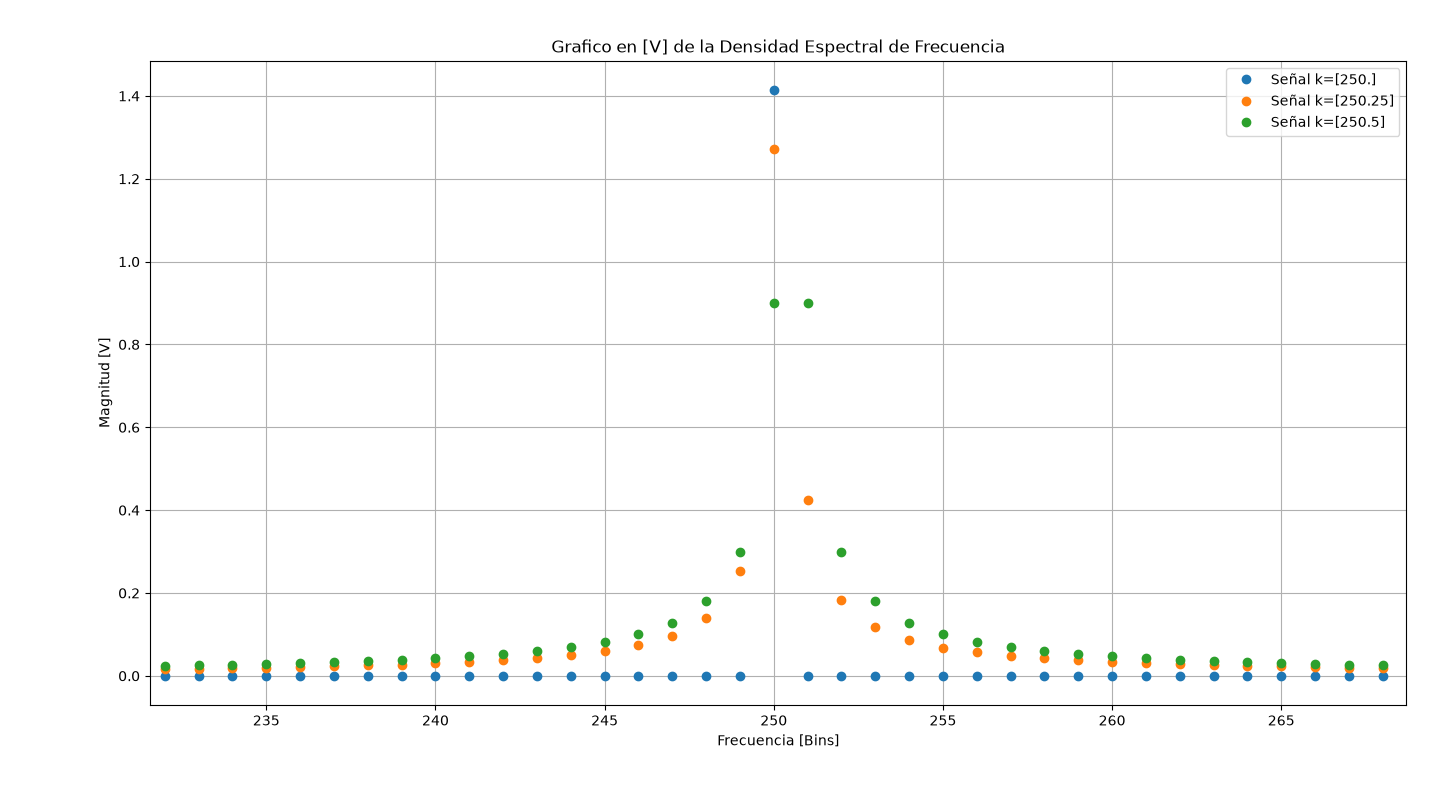

Como primer detalle, podemos ver que la que más amplitud pico tiene es la señal de frecuencia más cercana (en naranja).

Antes de seguir, veamos los gráficos en dB

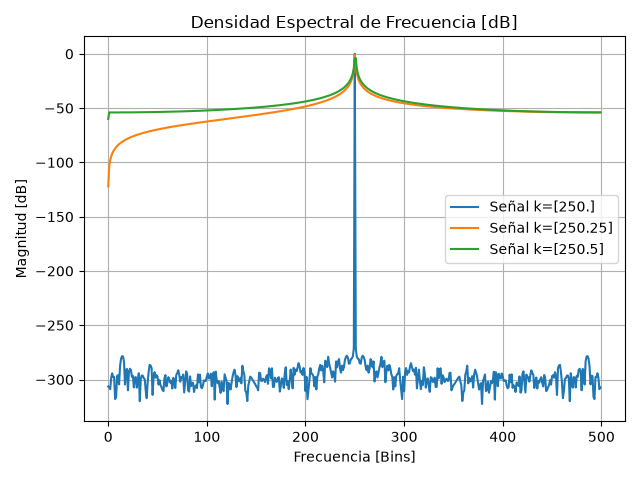

Vemos que las frecuencias más altas se mantienen bastante en plateau, mientras que las más bajas decaen muchísimo.

Por último, analicemos la Identidad de Parseval, que establece que:

$\sum_{n=0}^{N-1} P(x(n))=\frac{\sum_{k=0}^{N-1}P(X(k))} {N}$

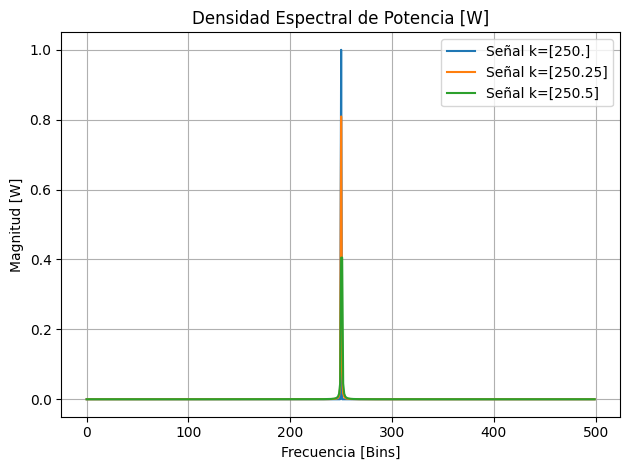

[1.    0.999 1.   ]
[1.    0.999 1.   ]
[1.         0.998998   0.99999699]


In [7]:
#modulo **2 de la señal
pds = modulo**2/2 #densidad espectral de potencia. Lo divido por dos porque antes lo multipliqué por dos dentro de la expresión por la simetría

#%% PDS
plt.figure()
plt.plot(eje_frecuencias[:], pds[0,:], label = f'Señal k={k_0[0]}')
plt.plot(eje_frecuencias[:], pds[1,:], label = f'Señal k={k_0[1]}')
plt.plot(eje_frecuencias[:], pds[2,:], label = f'Señal k={k_0[2]}')
plt.xlabel("Frecuencia [Bins]")
plt.ylabel("Magnitud [W]")
plt.title("Densidad Espectral de Potencia [W]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


#%% Parseval
# Vamos a verificar la Relación de Parseval
pot_xx = np.mean(xx**2,axis=1)
# Debiera ser sin dividir por N,
#pero al transformado que ya tiene 1/N lo vamos a elevar al cuadrado
pot_fft = np.sum(np.abs(fft)**2, axis = 1)
pot_pds = np.sum(pds, axis=1)

print(pot_xx)
print(pot_fft)
print(pot_pds)

Vemos cómo se distribuye en el grafico de PDS las potencias de cada Bin. Vemos que se cumple con la identidad de parseval a menos de un error que se debe a que como k₀ no es entero, la ventana no contiene un número entero de ciclos del término de doble frecuencia y el promedio de $Sen^2$ no es exactamente 0.5, pero por lo demás se cumple a la perfección.


---

Cómo se explica el fenómeno del derrame espectral? Sucede que en nuestra operación, lo que estamos haciendo es lo siguiente:

$FFT((f.g)(n)) = F*G$

Como vimos con Mariano, multiplicar en un dominio es convolucionar en el otro, y convolucionar una función por una delta es invariante en la forma pero implica un traslado centrado en la posición del pulso.

En nuestro caso, f es nuestra ventana implícita (vale 1) y g es nuestra sinusoidal de frecuencia $k_0$, por lo que el resultado es:

*   F es una Sinc()
*   G es un corrimiento

Por lo tanto, nuestro resultado es una Sinc() centrada en $k_0$. Acá viene lo interesante (si es que eso no es suficientemente impactante): si $k_0$ coincide con un Bin, los ceros de la Sinc() caen en los Bins que no son el central, y en el central tenemos la amplitud pico, que con la normalización, va a resultar siento la misma amplitud pico de la funcion que creamos en la primer celda de código (vmax), y entonces se cumple Parseval y lo vemos claramente en nuestro PDS y en nuestra DEF. Si $k_0$ no coincidiera con un bin, como son el resto de los casos estudiados, lo que vemos es el muestreo de la Sinc(), porque no olvidemos que la DFT es un muestreo de nuestra DTFT... Wow... esto sí que es revelador. Acá dejo alguna imagen del Holton para mostrar esto.



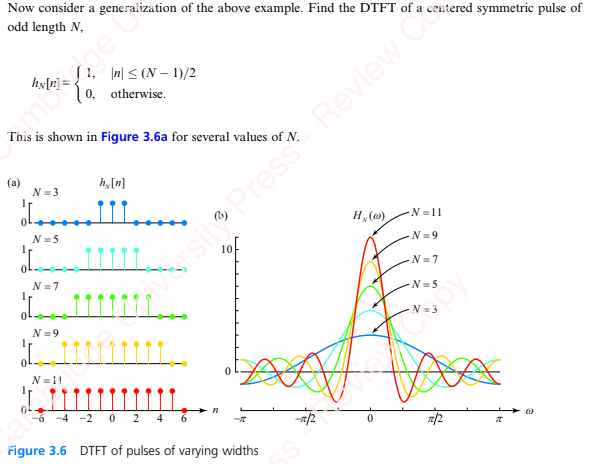

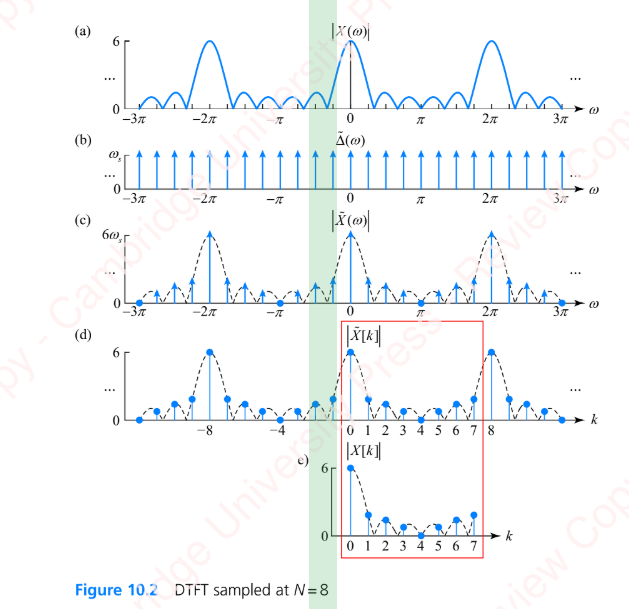

## Zero Padding
Ahora vamos a ver una forma de aumentar la resolución espectral de frecuencia de una manera muy económica: sumando muestreos que no son de nuestra señal, pero que tampoco van a hacerle nada ya que su amplitud es igual a 0 (cero).

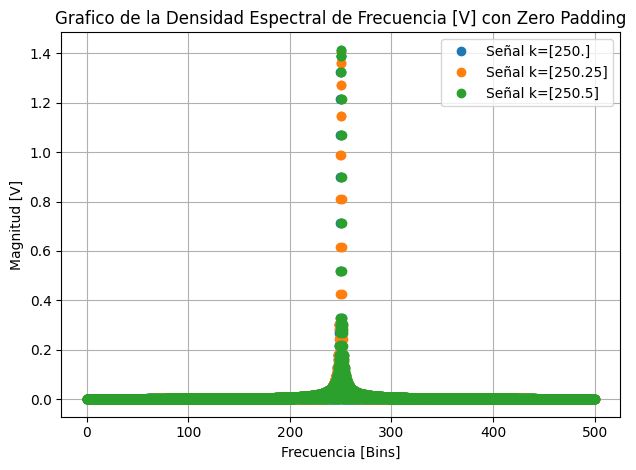

In [8]:
zp = 9*N # Zero Padding
N_zp = N+zp
eje_frecuencias = np.arange(N_zp//2) * fs/N_zp
xx_zp = np.hstack([xx,np.zeros((3,zp))]) #Concatenamos los dos vectores.
# Nuestro N ahora es M y vale N+9N=10N


#%% FFT
fft_zp = np.fft.fft(xx_zp,axis=1)/N
modulo = np.abs(fft_zp[:,:N_zp//2])
modulo[:, 1:] = 2 * modulo[:, 1:] # Por la simetría en la f_nyquist
modulo_db = 20*np.log10(modulo/vmax)




 Con un poquito de zoom:

 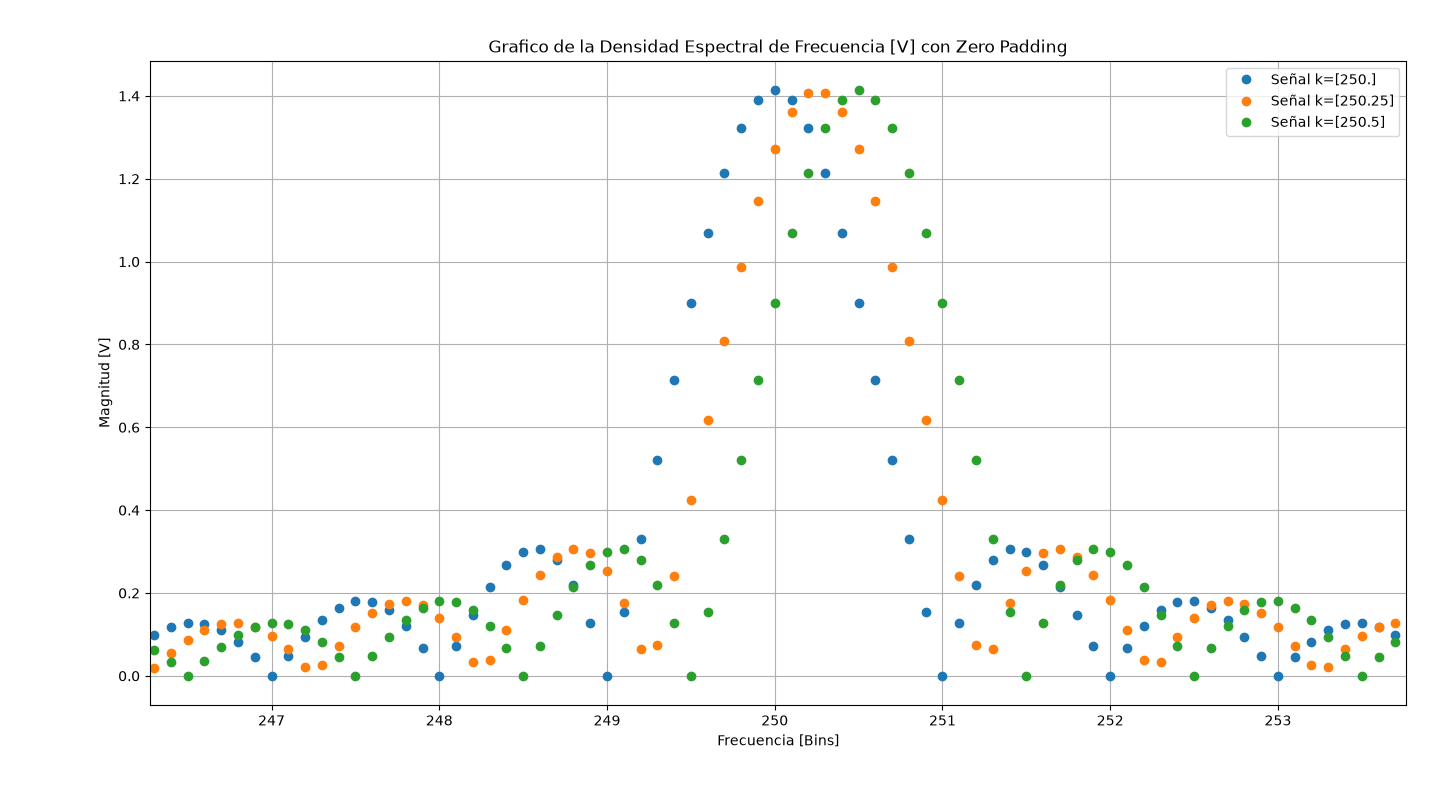

Vemos claramente las Sinc dezplazadas y cómo caen los ceros de la azul en los Bins.
Nuestra PDS lo muestra claramente:

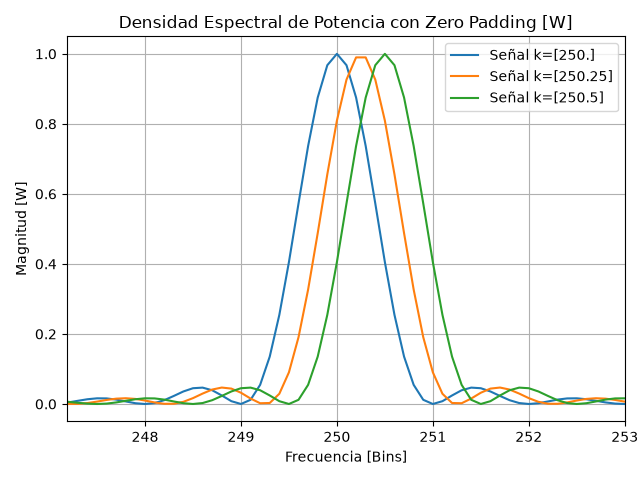

Algo que se me ocurrió hacer es añarirle, en vez de 9N ceros, los necesarios para que la frecuencia, digamos la 250,5Hz, caiga en un Bin. 250.5*4 = 1002 = N. Veamos si funciona:

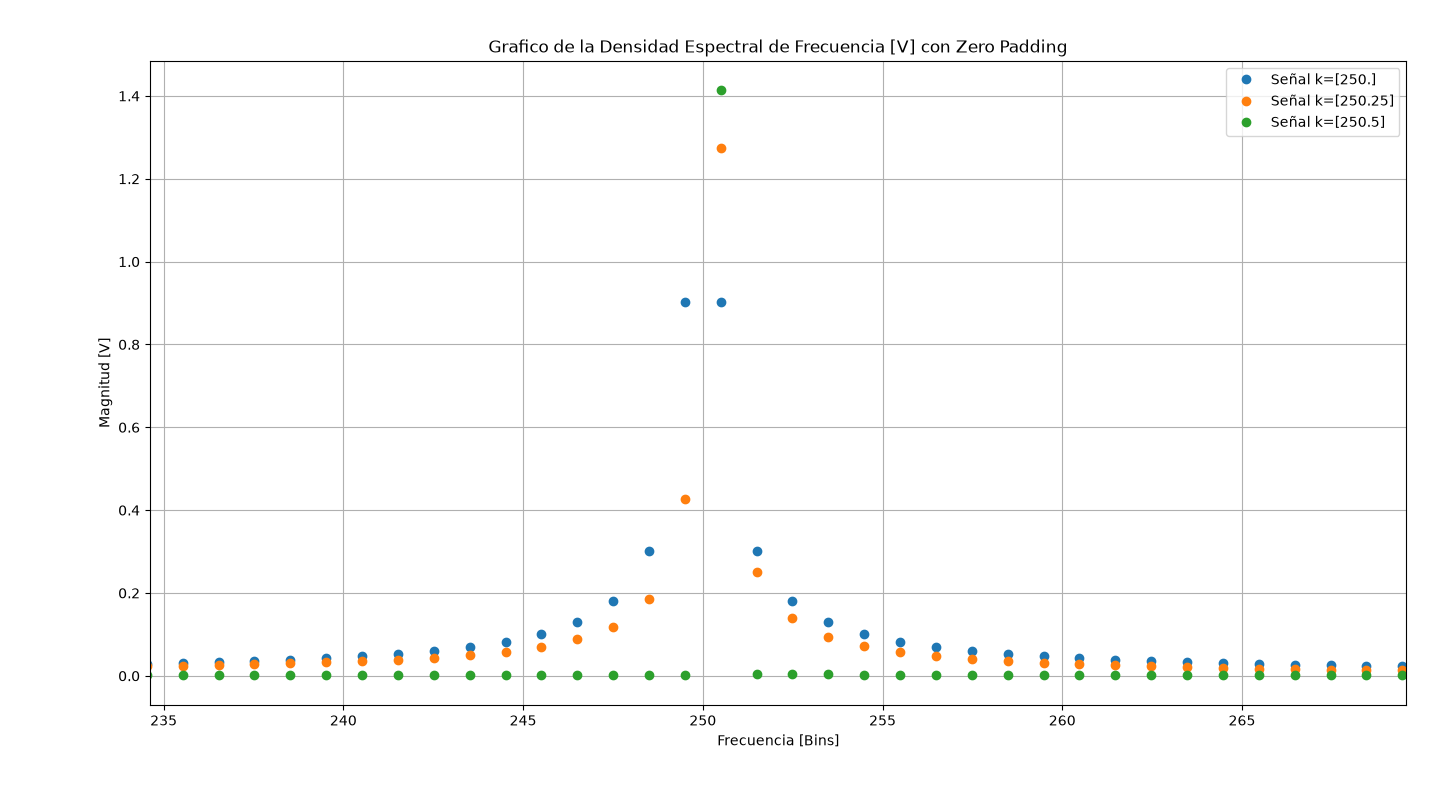

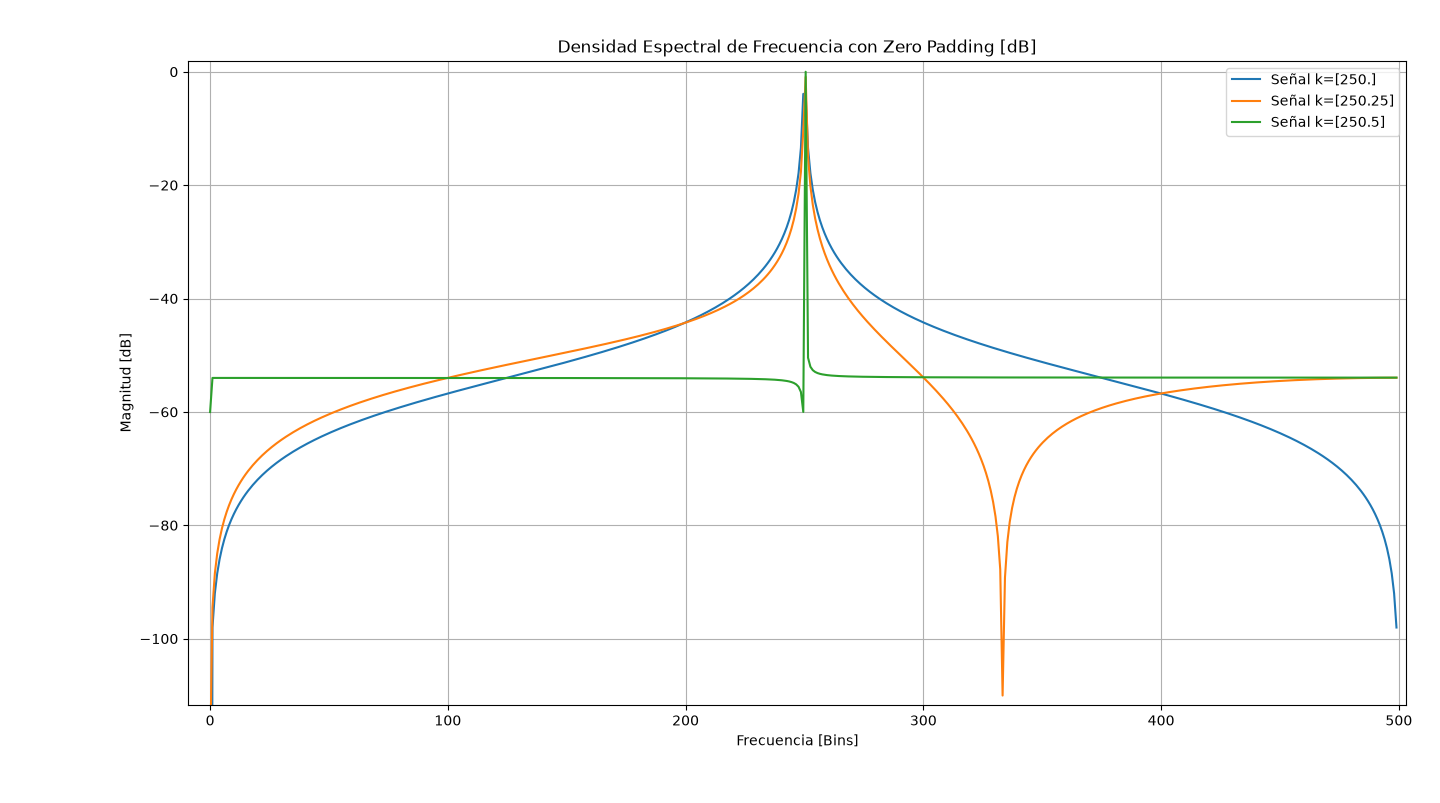

Funciona! Ademas vemos un comportamiento raro en el gráfico de la DEF, en la frecuencia 250.5. Eso se debe a que al añadir 2 ceros al final de nuestro vector, el ciclo fue completo, pero no es una autofunción, ya que los ultimos dos valores son constantemente iguales a 0. Si extendemos la funcion a esos dos valores, lo deberíamos solucionar.

## Conclusiones
En este Trabajo, vimos cómo la DFT genera estos efectos no deseados en nuestra señal. Se pueden aminorar cambiando nuestra ventana, algo de la TS4, pero vimos que era debida a la Sinc que se crea, y que si justo cae en la frecuencia de un Bin, la Sinc está centrada en ese Bin y los demas Bins reciben amplitud 0 porque los ceros de la Sinc caen justo en los Bins. Vimos que cuanto más cerca estaba una frecuencia de señal a uno de nuestros bins, menor era el desparramo y más aporte de amplitud recibía.

Por último, vimos que al multiplicar por un factor de 10 la cantidad de "muestras" y llenarlas con ceros, podíamos tomar 10 veces más valores en nuestra DTFT ($Δf_m = f_s/M = f_s/(10N)$), pudiendo develar el misterio del derrame espectral, que no es más que una consecuencia de discretizar el espectro de una señal discretizada en el tiempo.